# Desafio: Analisando Dados de Preços de Casas nos EUA
**Dataset:** House Prices - Advanced Regression Techniques (Kaggle)  
**Objetivo:** Realizar a análise exploratória dos dados e a engenharia de features para preparar o dataset para os modelos de Machine Learning.
---

## Importação das bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, silhouette_score
import plotly.express as px
import plotly.graph_objects as go
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

---
### 1. Análise exploratória de dados (felipe)


### 1.1 Carregando o dataset

In [ ]:
df = pd.read_csv("train.csv")

print(f"O dataset tem {df.shape[0]} linhas e {df.shape[1]} colunas")
df.head()

O dataset tem 1460 linhas e 81 colunas


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### 1.2 Identificação das variáveis


In [3]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Variáveis numéricas: {len(numeric_cols)}")
print(f"Variáveis categóricas: {len(categorical_cols)}")

print(f"\nNuméricas: {numeric_cols}")
print(f"\nCategóricas: {categorical_cols}")

Variáveis numéricas: 38
Variáveis categóricas: 43

Numéricas: ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']

Categóricas: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'Ki

### 1.3 Estatísticas descritivas


In [4]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [5]:
df[categorical_cols].describe().T

,count,unique,top,freq
MSZoning,1460,5,RL,1151
Street,1460,2,Pave,1454
Alley,91,2,Grvl,50
LotShape,1460,4,Reg,925
LandContour,1460,4,Lvl,1311
Utilities,1460,2,AllPub,1459
LotConfig,1460,5,Inside,1052
LandSlope,1460,3,Gtl,1382
Neighborhood,1460,25,NAmes,225
Condition1,1460,9,Norm,1260


**Insight:** Analisando o resumo estatístico, percebe-se que as variáveis relacionadas à área (como `LotArea` e `GrLivArea`) possuem um gap muito grande entre o terceiro quartil (75%) e o valor máximo. Isso sugere forte assimetria e sinaliza que vamos lidar com valores atípicos (outliers) pesados na ponta superior.

### 1.4 Valores faltantes


In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Faltantes': missing,
    'Porcentagem': missing_pct.round(2)
})
missing_df = missing_df[missing_df['Faltantes'] > 0].sort_values(by='Faltantes', ascending=False)

print(f"{len(missing_df)} colunas possuem valores faltantes\n")
missing_df

19 colunas possuem valores faltantes



,Faltantes,Porcentagem
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


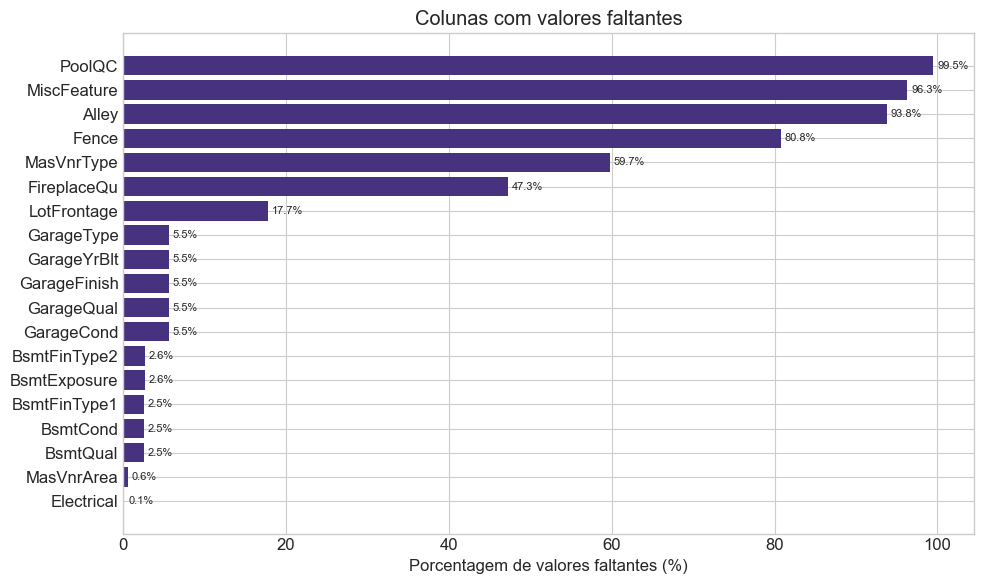

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(missing_df.index[::-1], missing_df['Porcentagem'][::-1])
ax.set_xlabel('Porcentagem de valores faltantes (%)')
ax.set_title('Colunas com valores faltantes')

for i, (val, name) in enumerate(zip(missing_df['Porcentagem'][::-1], missing_df.index[::-1])):
    ax.text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.show()

**Insight:** Temos colunas com mais de 80% de valores ausentes (ex: `PoolQC`, `MiscFeature`, `Alley`). Mas se a gente cruzar isso com o dicionário de dados, vemos que a ausência não é erro de coleta, mas sim a falta daquele item na casa (ex: a casa não tem piscina). O tratamento correto aqui não é excluir a coluna nem preencher com média, mas sim categorizar como 'None' na etapa de features.

### 1.5 Distribuição das variáveis


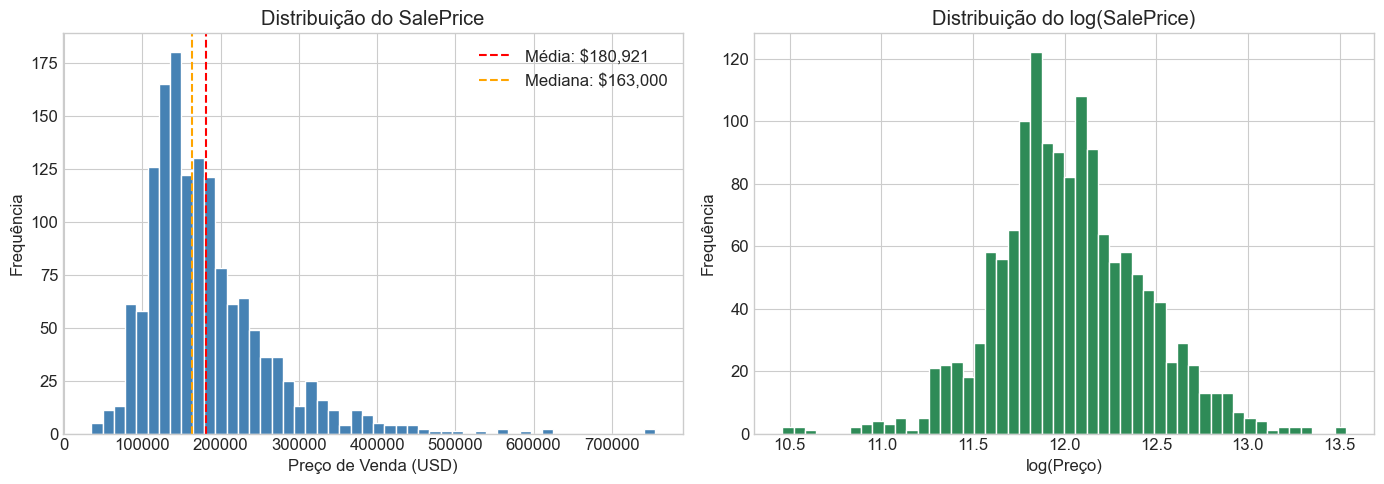

Assimetria (skewness): 1.88
Curtose (kurtosis): 6.54

A distribuição é assimétrica para direita, ou seja, a maioria das casas custa abaixo da média.
Aplicando log a distribuição fica mais próxima de uma normal.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição do SalePrice')
axes[0].set_xlabel('Preço de Venda (USD)')
axes[0].set_ylabel('Frequência')
axes[0].axvline(df['SalePrice'].mean(), color='red', linestyle='--', label=f"Média: ${df['SalePrice'].mean():,.0f}")
axes[0].axvline(df['SalePrice'].median(), color='orange', linestyle='--', label=f"Mediana: ${df['SalePrice'].median():,.0f}")
axes[0].legend()

axes[1].hist(np.log1p(df['SalePrice']), bins=50, color='seagreen', edgecolor='white')
axes[1].set_title('Distribuição do log(SalePrice)')
axes[1].set_xlabel('log(Preço)')
axes[1].set_ylabel('Frequência')

plt.tight_layout()
plt.show()

print(f"Assimetria (skewness): {df['SalePrice'].skew():.2f}")
print(f"Curtose (kurtosis): {df['SalePrice'].kurtosis():.2f}")
print("\nA distribuição é assimétrica para direita, ou seja, a maioria das casas custa abaixo da média.")
print("Aplicando log a distribuição fica mais próxima de uma normal.")

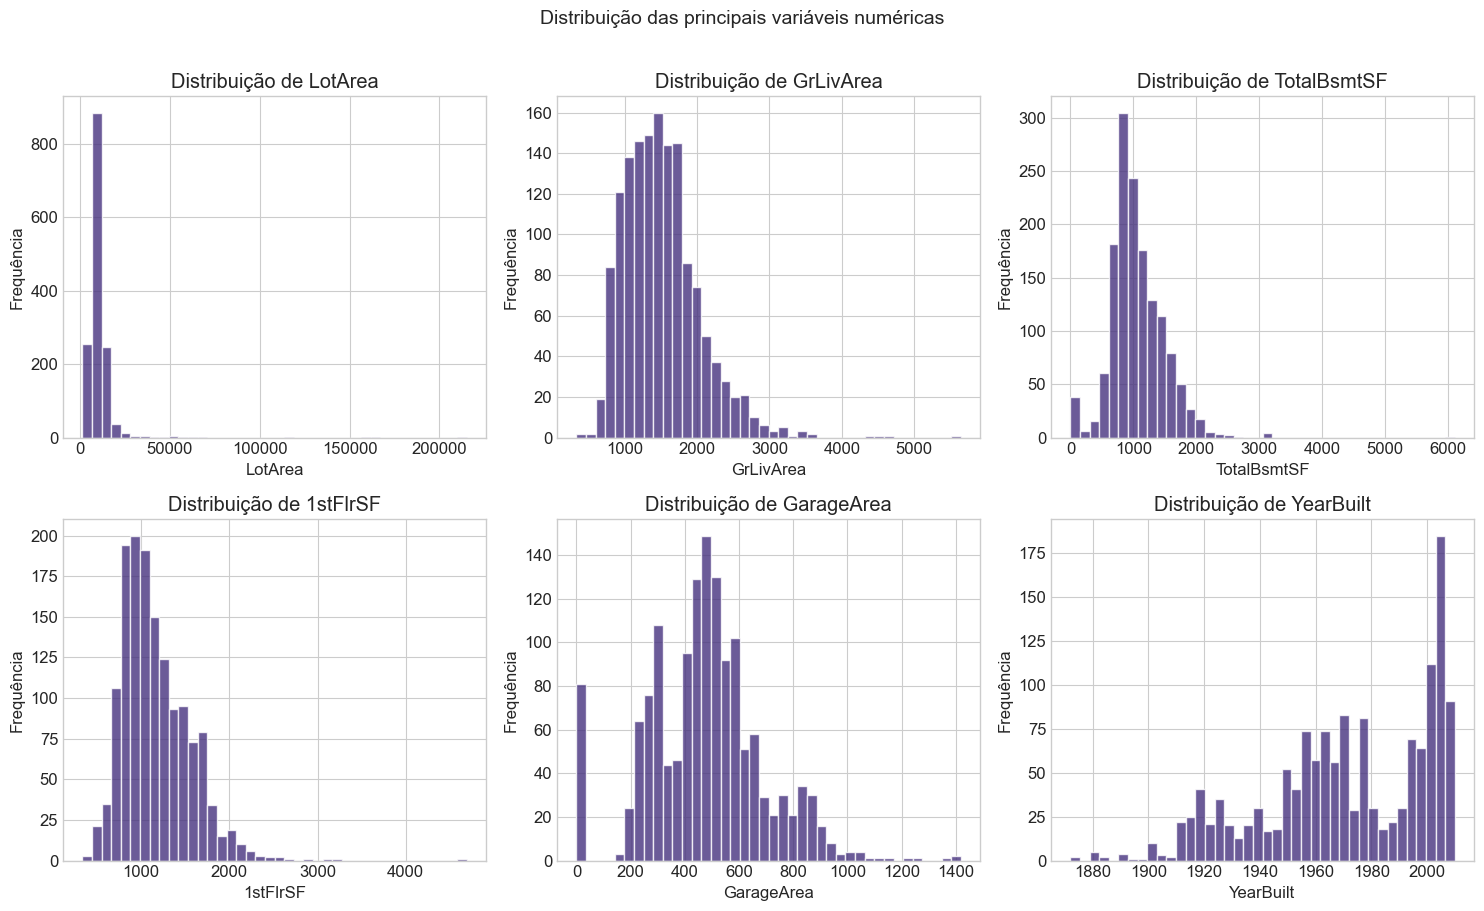

In [9]:
vars_importantes = ['LotArea', 'GrLivArea', 'TotalBsmtSF', '1stFlrSF', 'GarageArea', 'YearBuilt']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(vars_importantes):
    axes[i].hist(df[col].dropna(), bins=40, edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribuição de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequência')

plt.suptitle('Distribuição das principais variáveis numéricas', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Insight:** A variável target (`SalePrice`) sofre de assimetria à direita (positive skew). A aplicação do log ajuda bastante a normalizar a distribuição, estabilizando a variância. Isso costuma melhorar bem a performance de modelos lineares simples, além de facilitar a convergência do gradiente em modelos mais complexos.

### 1.6 Análise de outliers


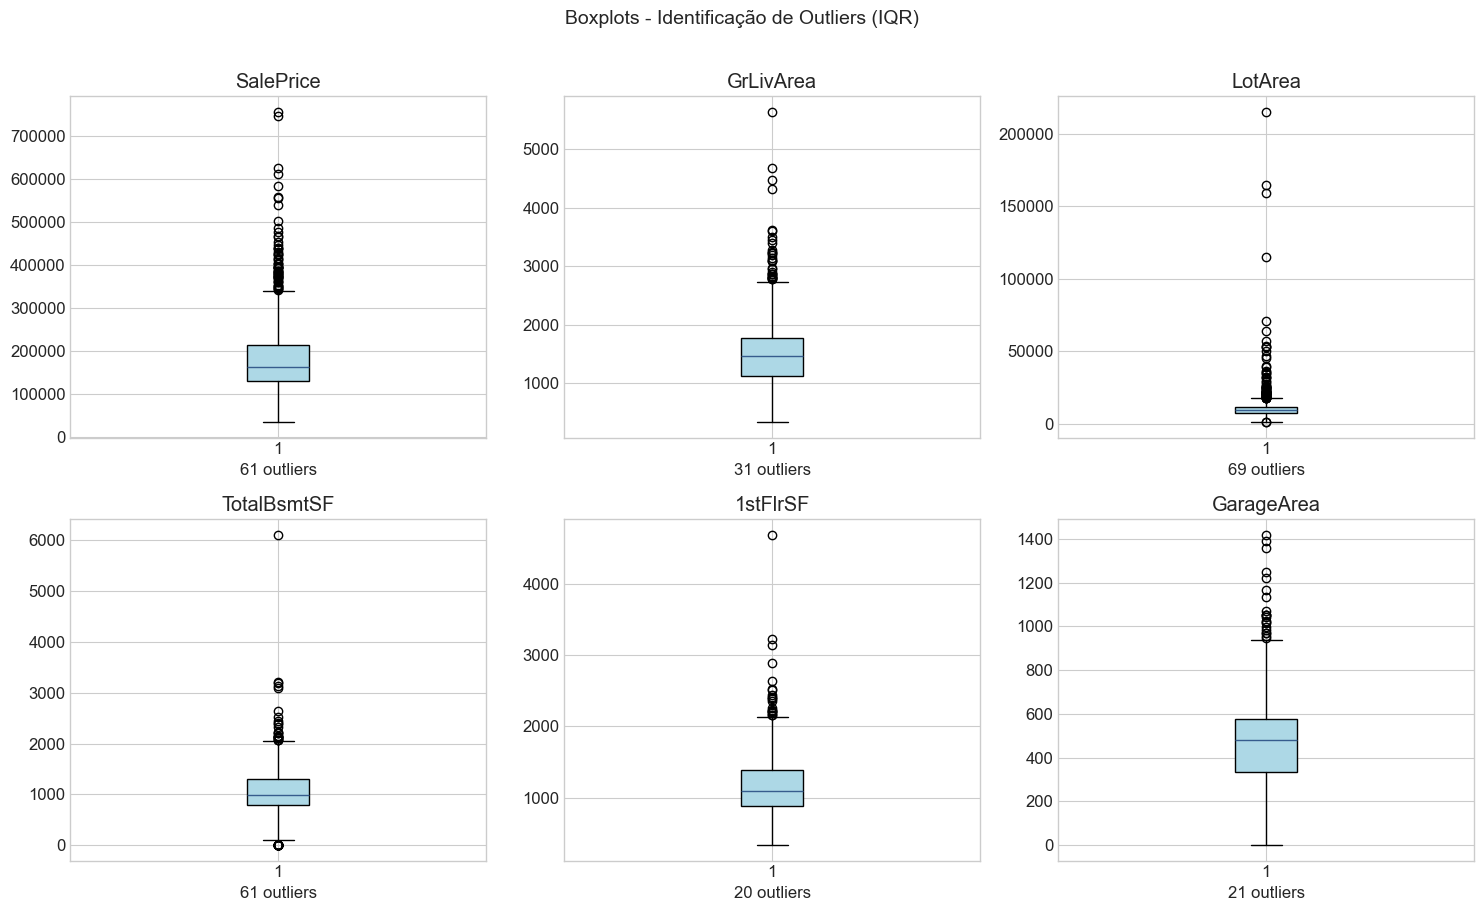

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

outlier_cols = ['SalePrice', 'GrLivArea', 'LotArea', 'TotalBsmtSF', '1stFlrSF', 'GarageArea']

for i, col in enumerate(outlier_cols):
    data = df[col].dropna()
    axes[i].boxplot(data, patch_artist=True, boxprops=dict(facecolor='lightblue'))
    axes[i].set_title(f'{col}')
    
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)).sum()
    axes[i].set_xlabel(f'{n_outliers} outliers')

plt.suptitle('Boxplots - Identificação de Outliers (IQR)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [11]:
print("Resumo de outliers (método IQR):")
print(f"{'Variável':<18} {'Q1':>10} {'Q3':>10} {'IQR':>10} {'Outliers':>10}")
print("-" * 60)

for col in outlier_cols:
    data = df[col].dropna()
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)).sum()
    print(f"{col:<18} {Q1:>10.1f} {Q3:>10.1f} {IQR:>10.1f} {n_outliers:>10}")

Resumo de outliers (método IQR):
Variável                   Q1         Q3        IQR   Outliers
------------------------------------------------------------
SalePrice            129975.0   214000.0    84025.0         61
GrLivArea              1129.5     1776.8      647.2         31
LotArea                7553.5    11601.5     4048.0         69
TotalBsmtSF             795.8     1298.2      502.5         61
1stFlrSF                882.0     1391.2      509.2         20
GarageArea              334.5      576.0      241.5         21


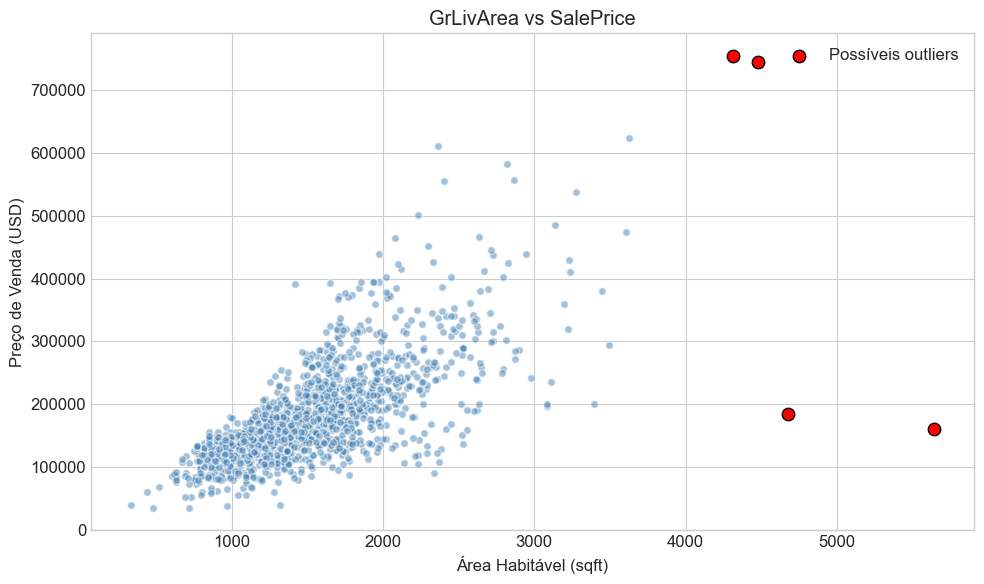

Existem 4 casas com área > 4000 sqft que parecem ser outliers.


In [12]:
plt.figure(figsize=(10, 6))
plt.scatter(df['GrLivArea'], df['SalePrice'], alpha=0.5, color='steelblue', edgecolors='white', s=30)

outliers = df['GrLivArea'] > 4000
plt.scatter(df.loc[outliers, 'GrLivArea'], df.loc[outliers, 'SalePrice'],
           color='red', s=80, edgecolors='black', label='Possíveis outliers')

plt.xlabel('Área Habitável (sqft)')
plt.ylabel('Preço de Venda (USD)')
plt.title('GrLivArea vs SalePrice')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Existem {outliers.sum()} casas com área > 4000 sqft que parecem ser outliers.")

**Insight:** O gráfico de dispersão da área habitável pelo preço revela um comportamento estranho: há imóveis com áreas enormes (> 4000 sqft), porém vendidos por preços muito abaixo da tendência geral. É bem provável que essas instâncias sejam transações atípicas (ex: vendas entre familiares) ou ruído agrícola. Manter esses pontos pode puxar a reta de regressão e piorar a generalização do modelo.

### 1.7 Correlação entre as variáveis


In [13]:
corr_matrix = df[numeric_cols].corr()
corr_saleprice = corr_matrix['SalePrice'].drop('SalePrice').sort_values(ascending=False)

print("Variáveis mais correlacionadas com SalePrice:")
print("-" * 45)
for col, val in corr_saleprice.head(15).items():
    print(f"  {col:<20} {val:>+.4f}")

Variáveis mais correlacionadas com SalePrice:
---------------------------------------------
  OverallQual          +0.7910
  GrLivArea            +0.7086
  GarageCars           +0.6404
  GarageArea           +0.6234
  TotalBsmtSF          +0.6136
  1stFlrSF             +0.6059
  FullBath             +0.5607
  TotRmsAbvGrd         +0.5337
  YearBuilt            +0.5229
  YearRemodAdd         +0.5071
  GarageYrBlt          +0.4864
  MasVnrArea           +0.4775
  Fireplaces           +0.4669
  BsmtFinSF1           +0.3864
  LotFrontage          +0.3518


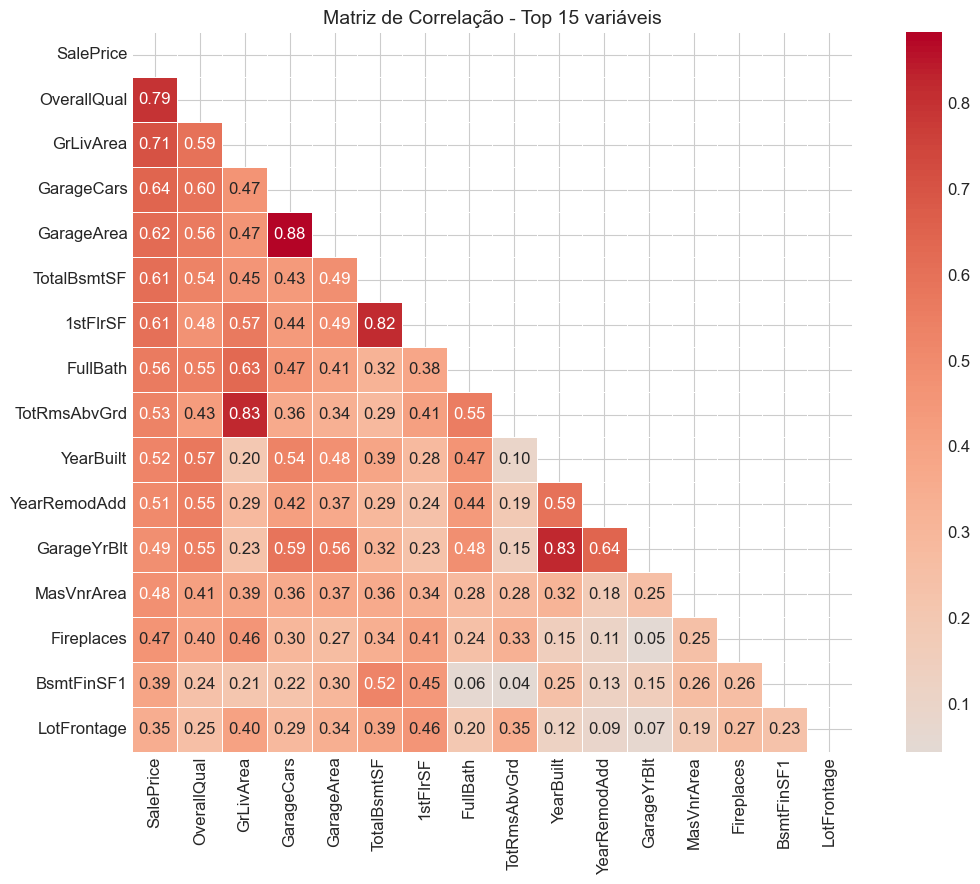

OverallQual (qualidade geral) e GrLivArea (área habitável) são as variáveis com maior correlação positiva com o preço.
GarageCars e GarageArea tem alta correlação entre si, o que indica multicolinearidade.


In [14]:
top_cols = corr_matrix['SalePrice'].abs().sort_values(ascending=False).head(16).index.tolist()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(df[top_cols].corr(), dtype=bool))

sns.heatmap(df[top_cols].corr(), mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax)

ax.set_title('Matriz de Correlação - Top 15 variáveis', fontsize=14)
plt.tight_layout()
plt.show()

print("OverallQual (qualidade geral) e GrLivArea (área habitável) são as variáveis com maior correlação positiva com o preço.")
print("GarageCars e GarageArea tem alta correlação entre si, o que indica multicolinearidade.")

---
### 2. Featuring Engineering (Felipe)


In [15]:
df_fe = df.copy()

**Insight:** A matriz deixa claro que a Qualidade Geral (`OverallQual`) e a Área Habitável (`GrLivArea`) são de longe os maiores drivers de preço. Vale notar também a forte multicolinearidade (correlação redundante) entre `GarageCars` e `GarageArea`, e entre `TotalBsmtSF` e `1stFlrSF`. Dependendo do modelo (como regressão linear sem regularização), pode ser necessário dropar um dos pares para evitar variância inflada nos coeficientes.

### 2.1 Tratamento de valores faltantes
- **Categóricas**: preenchemos com a moda (valor mais frequente)
- **Numéricas**: preenchemos com a mediana (mais robusta a outliers que a média)

In [16]:
cols_none = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
             'MasVnrType']

for col in cols_none:
    if col in df_fe.columns:
        df_fe[col] = df_fe[col].fillna('None')

for col in categorical_cols:
    if df_fe[col].isnull().sum() > 0:
        df_fe[col] = df_fe[col].fillna(df_fe[col].mode()[0])

for col in numeric_cols:
    if df_fe[col].isnull().sum() > 0:
        df_fe[col] = df_fe[col].fillna(df_fe[col].median())

print(f"Valores faltantes restantes: {df_fe.isnull().sum().sum()}")

Valores faltantes restantes: 0


### 2.2 Criação de novas features
| Nova variável | Como é calculada | Por que |
|---|---|---|
| TotalAreaSF | 1stFlrSF + 2ndFlrSF + TotalBsmtSF | Área total construída da casa |
| HouseAge | YrSold - YearBuilt | Idade da casa quando foi vendida |
| RemodAge | YrSold - YearRemodAdd | Tempo desde a última reforma |
| TotalBath | FullBath + 0.5*HalfBath + BsmtFullBath + 0.5*BsmtHalfBath | Número total de banheiros |
| TotalPorchSF | Soma de todas as áreas de varanda | Área total de varanda |
| HasPool | 1 se tem piscina, 0 se não | Indicador binário |
| HasGarage | 1 se tem garagem, 0 se não | Indicador binário |

In [17]:
df_fe['TotalAreaSF'] = df_fe['1stFlrSF'] + df_fe['2ndFlrSF'] + df_fe['TotalBsmtSF']
df_fe['HouseAge'] = df_fe['YrSold'] - df_fe['YearBuilt']
df_fe['RemodAge'] = df_fe['YrSold'] - df_fe['YearRemodAdd']
df_fe['TotalBath'] = (df_fe['FullBath'] + 0.5 * df_fe['HalfBath'] +
                      df_fe['BsmtFullBath'] + 0.5 * df_fe['BsmtHalfBath'])
df_fe['TotalPorchSF'] = (df_fe['OpenPorchSF'] + df_fe['EnclosedPorch'] +
                         df_fe['3SsnPorch'] + df_fe['ScreenPorch'])
df_fe['HasPool'] = (df_fe['PoolArea'] > 0).astype(int)
df_fe['HasGarage'] = (df_fe['GarageArea'] > 0).astype(int)

new_features = ['TotalAreaSF', 'HouseAge', 'RemodAge', 'TotalBath', 'TotalPorchSF', 'HasPool', 'HasGarage']

print("Correlação das novas features com SalePrice:")
print("-" * 40)
for feat in new_features:
    corr = df_fe[feat].corr(df_fe['SalePrice'])
    print(f"  {feat:<18} {corr:>+.4f}")

Correlação das novas features com SalePrice:
----------------------------------------
  TotalAreaSF        +0.7823
  HouseAge           -0.5234
  RemodAge           -0.5091
  TotalBath          +0.6317
  TotalPorchSF       +0.1957
  HasPool            +0.0937
  HasGarage          +0.2368


**Insight:** O racional de criar variáveis como `HouseAge` e `RemodAge` (idade da casa no momento da venda) é que o modelo lida melhor com grandezas de "tempo decorrido" do que com anos arbitrários isolados. Além disso, consolidar cômodos fragmentados em atributos únicos (como `TotalAreaSF` e `TotalBath`) condensa a informação e ajuda a reduzir um pouco a dimensionalidade, isolando o real sinal preditivo.

### 2.3 Codificação de variáveis categóricas


In [18]:
le = LabelEncoder()

for col in categorical_cols:
    df_fe[col] = le.fit_transform(df_fe[col].astype(str))

print(f"{len(categorical_cols)} variáveis categóricas codificadas")
print(f"\nExemplo (primeiras 5 linhas de algumas colunas):")
df_fe[categorical_cols[:5]].head()

43 variáveis categóricas codificadas

Exemplo (primeiras 5 linhas de algumas colunas):


,MSZoning,Street,Alley,LotShape,LandContour
0,3,1,1,3,3
1,3,1,1,3,3
2,3,1,1,0,3
3,3,1,1,0,3
4,3,1,1,0,3


### 2.4 Normalização


In [19]:
all_numeric = df_fe.select_dtypes(include=['int64', 'float64']).columns.tolist()
cols_to_scale = [col for col in all_numeric if col not in ['Id', 'SalePrice']]

scaler = StandardScaler()
df_fe[cols_to_scale] = scaler.fit_transform(df_fe[cols_to_scale])

print(f"{len(cols_to_scale)} variáveis normalizadas")
print(f"\nVerificação (média e desvio padrão devem ser ~0 e ~1):")
df_fe[cols_to_scale[:5]].describe().loc[['mean', 'std']].round(4)

86 variáveis normalizadas

Verificação (média e desvio padrão devem ser ~0 e ~1):


,MSSubClass,MSZoning,LotFrontage,LotArea,Street
mean,-0.0000,-0.0000,0.0000,-0.0000,0.0000
std,1.0003,1.0003,1.0003,1.0003,1.0003


### 2.5 Seleção de variáveis importantes


In [20]:
corr_target = df_fe.corr()['SalePrice'].drop('SalePrice').abs().sort_values(ascending=False)

threshold = 0.3
selected = corr_target[corr_target >= threshold]

print(f"Variáveis com |correlação| >= {threshold}: {len(selected)} de {len(corr_target)}")
print(f"\n{'Variável':<25} {'Correlação':>12}")
print("-" * 38)
for feat, val in selected.items():
    real_corr = df_fe[feat].corr(df_fe['SalePrice'])
    print(f"  {feat:<23} {real_corr:>+.4f}")

Variáveis com |correlação| >= 0.3: 30 de 87

Variável                    Correlação
--------------------------------------
  OverallQual             +0.7910
  TotalAreaSF             +0.7823
  GrLivArea               +0.7086
  GarageCars              +0.6404
  ExterQual               -0.6369
  TotalBath               +0.6317
  GarageArea              +0.6234
  TotalBsmtSF             +0.6136
  1stFlrSF                +0.6059
  BsmtQual                -0.5937
  KitchenQual             -0.5892
  FullBath                +0.5607
  TotRmsAbvGrd            +0.5337
  HouseAge                -0.5234
  YearBuilt               +0.5229
  RemodAge                -0.5091
  YearRemodAdd            +0.5071
  MasVnrArea              +0.4726
  Fireplaces              +0.4669
  GarageYrBlt             +0.4668
  GarageFinish            -0.4257
  GarageType              -0.4153
  HeatingQC               -0.4002
  BsmtFinSF1              +0.3864
  Foundation              +0.3825
  LotFrontage             +

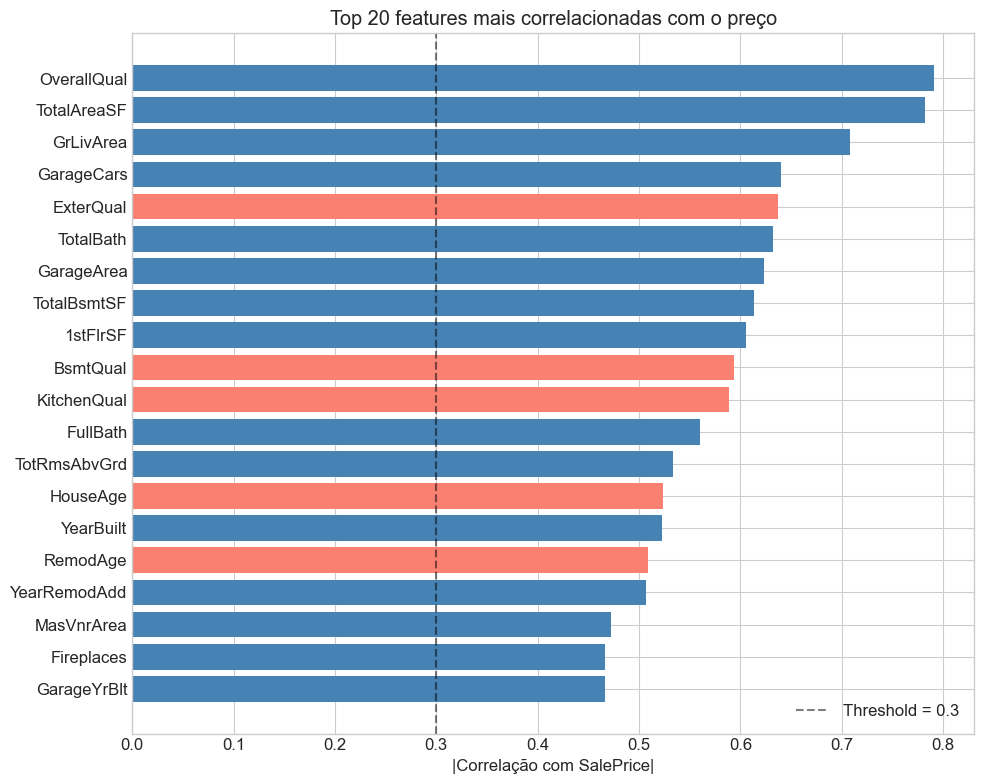

Azul = correlação positiva | Vermelho = correlação negativa


In [21]:
top20 = corr_target.head(20)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['steelblue' if df_fe[col].corr(df_fe['SalePrice']) > 0 else 'salmon' for col in top20.index]
ax.barh(top20.index[::-1], top20.values[::-1], color=colors[::-1])
ax.set_xlabel('|Correlação com SalePrice|')
ax.set_title('Top 20 features mais correlacionadas com o preço')
ax.axvline(x=threshold, color='black', linestyle='--', alpha=0.5, label=f'Threshold = {threshold}')
ax.legend()
plt.tight_layout()
plt.show()

print("Azul = correlação positiva | Vermelho = correlação negativa")

### 2.6 Salvando o dataset processado

In [371]:
df_fe.to_csv('dataset_processado.csv', index=False)

print("Resumo:")
print(f"  Dataset original:    {df.shape[0]} linhas x {df.shape[1]} colunas")
print(f"  Dataset processado:  {df_fe.shape[0]} linhas x {df_fe.shape[1]} colunas")
print(f"  Novas features:      {len(new_features)}")
print(f"  Valores faltantes:   0")
print(f"\nDataset salvo em 'dataset_processado.csv'")

Resumo:
  Dataset original:    1460 linhas x 81 colunas
  Dataset processado:  1460 linhas x 88 colunas
  Novas features:      7
  Valores faltantes:   0

Dataset salvo em 'dataset_processado.csv'


---
## 3. Aprendizagem Supervisionada


## Regressão Linear
### 3.1 Carregando o dataset

In [372]:
df = pd.read_csv("dataset_processado.csv")

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,SaleType,SaleCondition,SalePrice,TotalAreaSF,HouseAge,RemodAge,TotalBath,TotalPorchSF,HasPool,HasGarage
0,1,0.073375,-0.045532,-0.220875,-0.207142,0.064238,0.024699,0.750731,0.314667,-0.02618,...,0.313867,0.208502,208500,-0.001277,-1.043259,-0.869941,1.642256,-0.248063,-0.069409,0.24236
1,2,-0.872563,-0.045532,0.460320,-0.091886,0.064238,0.024699,0.750731,0.314667,-0.02618,...,0.313867,0.208502,181500,-0.052407,-0.183465,0.390141,0.368581,-0.828163,-0.069409,0.24236
2,3,0.073375,-0.045532,-0.084636,0.073480,0.064238,0.024699,-1.378933,0.314667,-0.02618,...,0.313867,0.208502,223500,0.169157,-0.977121,-0.821476,1.642256,-0.428750,-0.069409,0.24236
3,4,0.309859,-0.045532,-0.447940,-0.096897,0.064238,0.024699,-1.378933,0.314667,-0.02618,...,0.313867,-3.426284,140000,-0.114493,1.800676,0.632464,-0.268257,2.091355,-0.069409,0.24236
4,5,0.073375,-0.045532,0.641972,0.375148,0.064238,0.024699,-1.378933,0.314667,-0.02618,...,0.313867,0.208502,250000,0.944631,-0.944052,-0.724547,1.642256,-0.029337,-0.069409,0.24236


### 3.2 Visualizando a estrutura dos dados

In [373]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 88 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   float64
 2   MSZoning       1460 non-null   float64
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   float64
 5   Street         1460 non-null   float64
 6   Alley          1460 non-null   float64
 7   LotShape       1460 non-null   float64
 8   LandContour    1460 non-null   float64
 9   Utilities      1460 non-null   float64
 10  LotConfig      1460 non-null   float64
 11  LandSlope      1460 non-null   float64
 12  Neighborhood   1460 non-null   float64
 13  Condition1     1460 non-null   float64
 14  Condition2     1460 non-null   float64
 15  BldgType       1460 non-null   float64
 16  HouseStyle     1460 non-null   float64
 17  OverallQual    1460 non-null   float64
 18  OverallCond    1460

### 3.3 Separarando X e y

In [374]:
target = 'SalePrice'

X = df.drop(target, axis=1)
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1460, 87)
y shape: (1460,)


### 3.4 Divisão de treino/teste

In [375]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
    )

### 3.5 Treinamento do modelo

In [376]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### 3.6 Predição

In [377]:
y_pred = model.predict(X_test)

### 3.7 Avaliação

In [378]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("---MÉTRICAS---")
print(f"RMSE: {rmse:}")
print(f"MAE: {mae:}")
print(f"R²: {r2:}")

---MÉTRICAS---
RMSE: 38196.025556624394
MAE: 20749.776282814375
R²: 0.8097947428943406


### 3.8 Interpretação dos coeficientes

In [379]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coeficiente": model.coef_
})

coef_df.sort_values(by="Coeficiente", ascending=False)

,Feature,Coeficiente
71,PoolArea,86629.805167
17,OverallQual,12970.224780
46,GrLivArea,10267.619205
80,TotalAreaSF,8413.746542
54,TotRmsAbvGrd,8179.842642
...,...,...
27,ExterQual,-5781.945708
30,BsmtQual,-5888.048402
53,KitchenQual,-6647.369263
72,PoolQC,-39482.486229


#### 3.9 Intercepto

In [380]:
print("Intercepto:", model.intercept_)

Intercepto: 181141.20442981322


### 3.10 Gráfico de dispersão

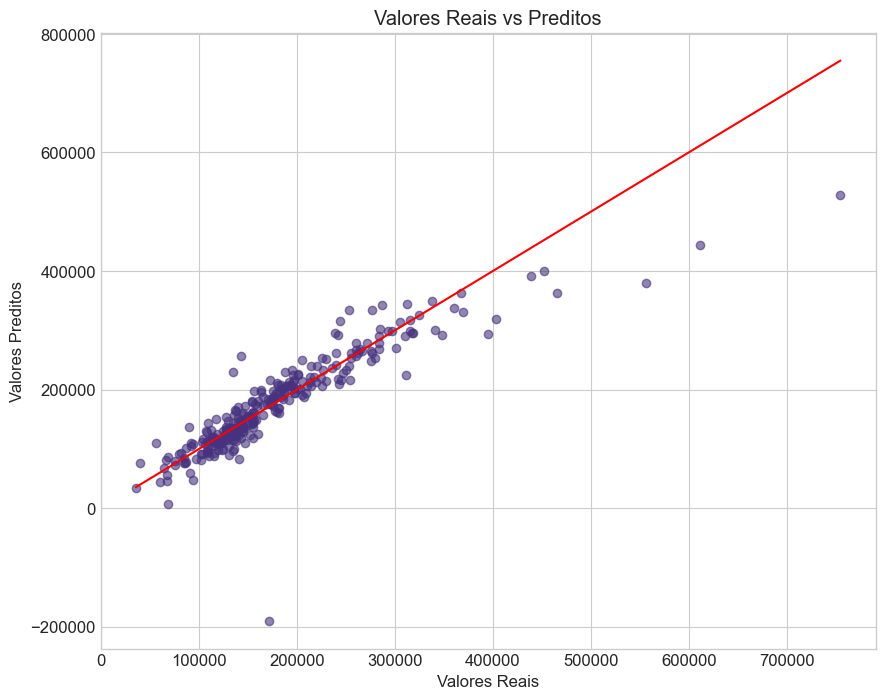

In [381]:
plt.figure(figsize=(10,8))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Valores Reais")
plt.ylabel("Valores Preditos")
plt.title("Valores Reais vs Preditos")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.show()

### 3.11 Gráfico de Resíduos

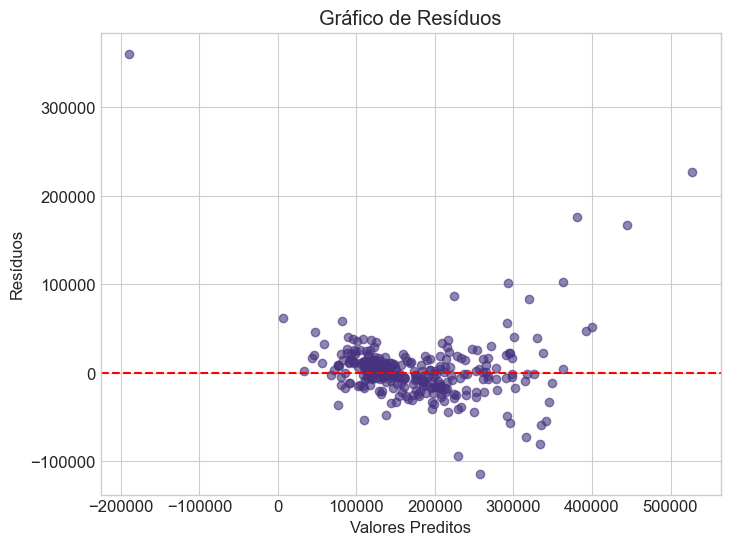

In [382]:
residuos = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuos, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Valores Preditos")
plt.ylabel("Resíduos")
plt.title("Gráfico de Resíduos")

plt.show()

### 3.12 Exemplo de boa e má previsão

In [383]:
resultados = pd.DataFrame({
    "Real": y_test,
    "Previsto": y_pred
})

resultados["Erro"] = abs(resultados["Real"] - resultados["Previsto"])

melhores = resultados.sort_values(by="Erro").head(1)

piores = resultados.sort_values(by="Erro", ascending=False).head(1)

print("EXEMPLO - BOA PREVISÃO")
print(f"Valor real:     $ {melhores['Real'].values[0]:,.2f}")
print(f"Valor previsto: $ {melhores['Previsto'].values[0]:,.2f}")
print(f"Erro:           $ {melhores['Erro'].values[0]:,.2f}")
print("\n")

print("EXEMPLO - ERRO ELEVADO")
print(f"Valor real:     $ {piores['Real'].values[0]:,.2f}")
print(f"Valor previsto: $ {piores['Previsto'].values[0]:,.2f}")
print(f"Erro:           $ {piores['Erro'].values[0]:,.2f}")

EXEMPLO - BOA PREVISÃO
Valor real:     $ 128,500.00
Valor previsto: $ 128,428.00
Erro:           $ 72.00


EXEMPLO - ERRO ELEVADO
Valor real:     $ 171,000.00
Valor previsto: $ -189,804.31
Erro:           $ 360,804.31


## Regressão Logística
### 3.13 Criando variável binária

In [384]:
mediana_preco = df['SalePrice'].median()

df['PrecoAlto'] = (df['SalePrice'] > mediana_preco).astype(int)

print(f"Mediana do preço: {mediana_preco}")
df[['SalePrice', 'PrecoAlto']].head()

Mediana do preço: 163000.0


,SalePrice,PrecoAlto
0,208500,1
1,181500,1
2,223500,1
3,140000,0
4,250000,1


### 3.14 Definindo X e y

In [385]:
X = df.drop(['SalePrice', 'PrecoAlto'], axis=1)
y = df['PrecoAlto']

### 3.15 Train test split

In [386]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 3.16 Treinando modelo

In [387]:
modelo_class = LogisticRegression(max_iter=1000)
modelo_class.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### 3.17 Previsões

In [388]:
y_pred = modelo_class.predict(X_test)

### 3.18 Métricas

In [389]:
acc = accuracy_score(y_test, y_pred)

print(f"Acurácia: {acc:.4f}")

Acurácia: 0.9486


### 3.19 Matriz de confusão

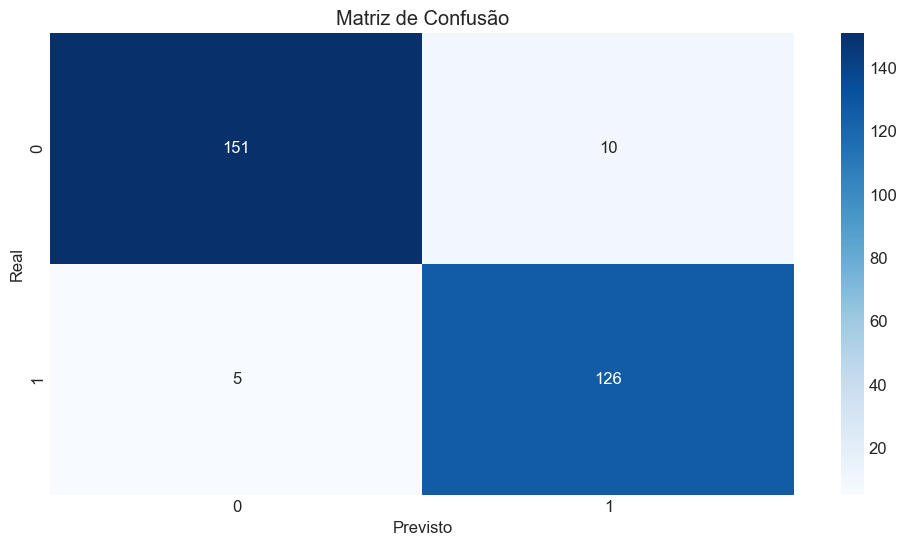

In [390]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de Confusão")
plt.show()

### 3.20 Classification Report

In [391]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.94      0.95       161
           1       0.93      0.96      0.94       131

    accuracy                           0.95       292
   macro avg       0.95      0.95      0.95       292
weighted avg       0.95      0.95      0.95       292



---
## 4. Aprendizagem não supervisionada
### 4.1 Clusterização e redução de dimensionalidade

### 4.1.1 Redução de Dimensionalidade

In [392]:
df = pd.read_csv('dataset_processado.csv')

X = df.drop(columns=['Id', 'SalePrice'])

pca = PCA(n_components=2, random_state=42)
componentes = pca.fit_transform(X)

df_pca = pd.DataFrame(data=componentes, columns=['Componente 1', 'Componente 2'])

variancia_explicada = pca.explained_variance_ratio_.sum() * 100
print(f"As duas componentes principais explicam {variancia_explicada:.2f}% da variância total.")

As duas componentes principais explicam 20.53% da variância total.


### 4.1.2 Método do Cotovelo (Elbow Method)

In [393]:
inercia = []
k_range = range(1, 11)

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans_temp.fit(X)
    inercia.append(kmeans_temp.inertia_)

fig_elbow = go.Figure(data=go.Scatter(x=list(k_range), y=inercia, mode='lines+markers'))
fig_elbow.update_layout(
    title='Método do Cotovelo para Escolha do Número de Clusters (k)',
    xaxis_title='Número de Clusters (k)',
    yaxis_title='Inércia (WCSS)',
    plot_bgcolor='white'
)

fig_elbow.add_vline(x=4, line_dash="dash", line_color="red", annotation_text="k=4 sugerido")
fig_elbow.show()

### 4.1.3 Clusterização

In [394]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')

df_pca['Cluster'] = kmeans.fit_predict(X).astype(str)

df_pca['SalePrice'] = df['SalePrice']
df_pca['OverallQual'] = df['OverallQual']
df_pca['GrLivArea'] = df['GrLivArea']

fig_clusters = px.scatter(
    df_pca,
    x='Componente 1',
    y='Componente 2',
    color='Cluster',
    hover_data=['SalePrice', 'OverallQual', 'GrLivArea'],
    title='Agrupamento de Casas nos EUA',
    color_discrete_sequence=px.colors.qualitative.Bold,
    opacity=0.7
)

fig_clusters.update_layout(
    plot_bgcolor='white',
    legend_title_text='Grupos (K=4)'
)

fig_clusters.show()

### 4.1.4 Silhouette Score

In [ ]:
score_silhueta = silhouette_score(X, df_pca['Cluster'])
print(f"Silhouette Score para k=4: {score_silhueta:.3f}")

Silhouette Score para k=4: 0.079
Valores mais próximos de 1 indicam clusters mais coesos e bem separados.



- **Silhouette Score (0.079):** Este valor baixo indica que os grupos (clusters) não são perfeitamente separados; eles possuem sobreposição.

- Isso reflete a realidade do mercado imobiliário. Não existem "barreiras rígidas" que separam uma casa de luxo de uma casa de alto padrão; existe um continuum. O mercado é fluido, e nosso modelo capturou essa transição suave entre os perfis de casas.

### 4.1.5 Análise de Perfil dos Clusters

In [396]:
df_fe['Cluster'] = df_pca['Cluster']
df_fe['SalePrice'] = df['SalePrice']

variaveis_perfil = ['SalePrice', 'OverallQual', 'GrLivArea', 'TotalBath', 'GarageCars']

resumo_clusters = df_fe.groupby('Cluster')[variaveis_perfil].mean().round(2)

print("Perfil Médio de cada Cluster:")
print("-" * 65)
print(resumo_clusters.sort_values(by='SalePrice'))

Perfil Médio de cada Cluster:
-----------------------------------------------------------------
         SalePrice  OverallQual  GrLivArea  TotalBath  GarageCars
Cluster                                                          
3        102715.44        -1.08      -0.62      -0.69       -1.80
0        136546.78        -0.53      -0.12      -0.81       -0.42
2        149437.26        -0.49      -0.52      -0.24       -0.16
1        245072.41         0.89       0.62       0.74        0.71


### Perfil dos Grupos Identificados:

Com base na análise, conseguimos segmentar o mercado em quatro personas distintas:

- **Cluster 3** (Oportunidades de Entrada): Casas com as menores métricas de qualidade (OverallQual), área (GrLivArea) e preço. São ideais para compradores de primeiro imóvel ou investidores focados em reforma.

- **Cluster 0 e 2** (Classe Média): Grupos de transição. Apresentam características medianas. O modelo mostra que, embora tenham preços próximos, o Cluster 2 tende a ter um acabamento ou área ligeiramente superior ao Cluster 0.

- **Cluster 1** (Alto Padrão): O grupo das casas "Premium". Apresenta pontuações máximas em todas as categorias. É onde se concentram os maiores investimentos em construção e área útil.

### 4.1.6 Discussão dos Resultados e Metodologia

### Por que utilizamos estas técnicas?

1. **PCA (Redução de Dimensionalidade):** Nosso dataset, após a Feature Engineering, tornou-se de alta dimensionalidade. Visualizar dezenas de colunas simultaneamente é impossível. Utilizamos o PCA para projetar esses dados em 2 dimensões.

- *Justificativa:* O PCA cria combinações lineares das variáveis originais, permitindo-nos ver a "estrutura" do mercado imobiliário em um plano 2D.

- *O que perdemos/ganhamos:* Obtivemos ~20% da variância explicada. Embora pareça baixo, é o "preço" de simplificar um problema complexo. Alternativas como o t-SNE poderiam gerar agrupamentos visualmente mais bonitos, mas o PCA é superior aqui por ser determinístico e permitir entender quais features influenciam cada componente.

2. **K-Means (Clusterização):** Escolhemos o K-Means por sua eficiência computacional e clareza.

- *Alternativas:* Poderíamos usar DBSCAN, que é excelente para detectar outliers e formas não esféricas. No entanto, o K-Means atende melhor nosso objetivo de segmentar o mercado em "perfis" de casas comparáveis.

---
### 4.2 Análise de Associação e Outlier

#### 4.2.1 Carregando o dataset processado

In [397]:
df_original = pd.read_csv('train.csv')
df_processado = pd.read_csv('dataset_processado.csv')

print(f'Dataset original:   {df_original.shape[0]} linhas x {df_original.shape[1]} colunas')
print(f'Dataset processado: {df_processado.shape[0]} linhas x {df_processado.shape[1]} colunas')

Dataset original:   1460 linhas x 81 colunas
Dataset processado: 1460 linhas x 88 colunas


### 4.2.2 Análise de Associação (Algoritmo Apriori)

In [398]:
colunas_assoc = ['OverallQual', 'GarageCars', 'FullBath', 'BedroomAbvGr',
                 'Fireplaces', 'CentralAir', 'SalePrice']

df_assoc = df_original[colunas_assoc].copy()
df_assoc['GarageCars'] = df_assoc['GarageCars'].fillna(0)
df_assoc['Fireplaces'] = df_assoc['Fireplaces'].fillna(0)

mediana_preco = df_assoc['SalePrice'].median()
mediana_qual  = df_assoc['OverallQual'].median()

df_bin = pd.DataFrame()
df_bin['Preco_Alto']          = (df_assoc['SalePrice']    >= mediana_preco).astype(bool)
df_bin['Qualidade_Alta']      = (df_assoc['OverallQual']  >= mediana_qual).astype(bool)
df_bin['Garagem_2_ou_mais']   = (df_assoc['GarageCars']   >= 2).astype(bool)
df_bin['2_ou_mais_Banheiros'] = (df_assoc['FullBath']     >= 2).astype(bool)
df_bin['3_ou_mais_Quartos']   = (df_assoc['BedroomAbvGr'] >= 3).astype(bool)
df_bin['Tem_Lareira']         = (df_assoc['Fireplaces']   >= 1).astype(bool)
df_bin['Ar_Central']          = (df_assoc['CentralAir']   == 'Y').astype(bool)

print('Proporção de cada característica no dataset:')
print((df_bin.mean() * 100).round(1).rename('% das casas').to_string())
print(f'\nMediana do preço: ${mediana_preco:,.0f}')

Proporção de cada característica no dataset:
Preco_Alto             50.1
Qualidade_Alta         63.2
Garagem_2_ou_mais      69.2
2_ou_mais_Banheiros    54.9
3_ou_mais_Quartos      71.6
Tem_Lareira            52.7
Ar_Central             93.5

Mediana do preço: $163,000


In [399]:
itemsets_frequentes = apriori(
    df_bin,
    min_support=0.20,
    use_colnames=True
)

regras = association_rules(
    itemsets_frequentes,
    metric='confidence',
    min_threshold=0.60,
    num_itemsets=len(itemsets_frequentes)
)

regras = regras.sort_values('lift', ascending=False)

print(f'Itemsets frequentes encontrados: {len(itemsets_frequentes)}')
print(f'Regras de associação geradas:    {len(regras)}')

Itemsets frequentes encontrados: 127
Regras de associação geradas:    1407


In [400]:
top_regras = regras[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10).copy()
top_regras['antecedents'] = top_regras['antecedents'].apply(lambda x: ', '.join(list(x)))
top_regras['consequents'] = top_regras['consequents'].apply(lambda x: ', '.join(list(x)))
top_regras[['support', 'confidence', 'lift']] = top_regras[['support', 'confidence', 'lift']].round(3)

print('Top 10 Regras de Associação (ordenadas por lift):')
top_regras

Top 10 Regras de Associação (ordenadas por lift):


,antecedents,consequents,support,confidence,lift
1384,"2_ou_mais_Banheiros, Qualidade_Alta, Tem_Lareira","Ar_Central, Garagem_2_ou_mais, 3_ou_mais_Quart...",0.247,0.732,1.954
1381,"Ar_Central, Garagem_2_ou_mais, 3_ou_mais_Quart...","2_ou_mais_Banheiros, Qualidade_Alta, Tem_Lareira",0.247,0.660,1.954
1355,"2_ou_mais_Banheiros, Ar_Central, Qualidade_Alt...","Garagem_2_ou_mais, 3_ou_mais_Quartos, Preco_Alto",0.247,0.738,1.949
1398,"Garagem_2_ou_mais, 3_ou_mais_Quartos, Preco_Alto","2_ou_mais_Banheiros, Ar_Central, Qualidade_Alt...",0.247,0.653,1.949
1368,"Ar_Central, Qualidade_Alta, 3_ou_mais_Quartos,...","2_ou_mais_Banheiros, Garagem_2_ou_mais, Tem_La...",0.247,0.672,1.947
1390,"2_ou_mais_Banheiros, Garagem_2_ou_mais, Tem_La...","Ar_Central, Qualidade_Alta, 3_ou_mais_Quartos,...",0.247,0.716,1.947
1042,"2_ou_mais_Banheiros, Qualidade_Alta, Tem_Lareira","Garagem_2_ou_mais, 3_ou_mais_Quartos, Preco_Alto",0.249,0.736,1.944
1056,"Garagem_2_ou_mais, 3_ou_mais_Quartos, Preco_Alto","2_ou_mais_Banheiros, Qualidade_Alta, Tem_Lareira",0.249,0.656,1.944
1389,"Qualidade_Alta, 3_ou_mais_Quartos, Preco_Alto","2_ou_mais_Banheiros, Garagem_2_ou_mais, Tem_La...",0.247,0.665,1.941
1370,"2_ou_mais_Banheiros, Garagem_2_ou_mais, Tem_La...","Qualidade_Alta, 3_ou_mais_Quartos, Preco_Alto",0.247,0.722,1.941


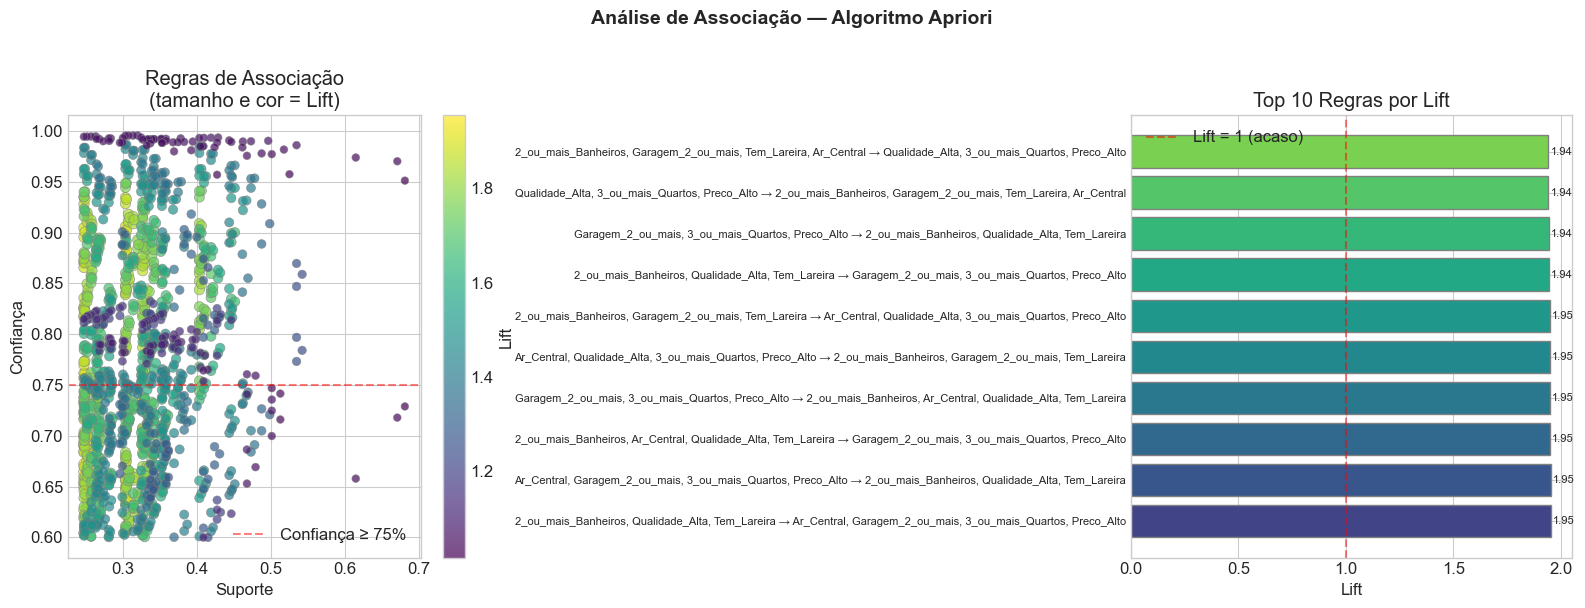

In [401]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Scatter Suporte x Confiança colorido por Lift
scatter = axes[0].scatter(
    regras['support'],
    regras['confidence'],
    c=regras['lift'],
    cmap='viridis',
    s=regras['lift'] * 30,
    alpha=0.7,
    edgecolors='gray',
    linewidths=0.5
)
plt.colorbar(scatter, ax=axes[0], label='Lift')
axes[0].set_xlabel('Suporte')
axes[0].set_ylabel('Confiança')
axes[0].set_title('Regras de Associação\n(tamanho e cor = Lift)')
axes[0].axhline(y=0.75, color='red', linestyle='--', alpha=0.5, label='Confiança ≥ 75%')
axes[0].legend()

# Gráfico 2: Top 10 regras por lift (barras horizontais)
regras_plot = regras.head(10).copy()
regras_plot['regra'] = [
    f"{', '.join(list(a))} → {', '.join(list(c))}"
    for a, c in zip(regras_plot['antecedents'], regras_plot['consequents'])
]

cores = plt.cm.viridis(np.linspace(0.2, 0.8, len(regras_plot)))
bars = axes[1].barh(range(len(regras_plot)), regras_plot['lift'], color=cores, edgecolor='gray')
axes[1].set_yticks(range(len(regras_plot)))
axes[1].set_yticklabels(regras_plot['regra'], fontsize=8)
axes[1].set_xlabel('Lift')
axes[1].set_title('Top 10 Regras por Lift')
axes[1].axvline(x=1, color='red', linestyle='--', alpha=0.5, label='Lift = 1 (acaso)')
axes[1].legend()

for bar, val in zip(bars, regras_plot['lift']):
    axes[1].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=8)

plt.suptitle('Análise de Associação — Algoritmo Apriori', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

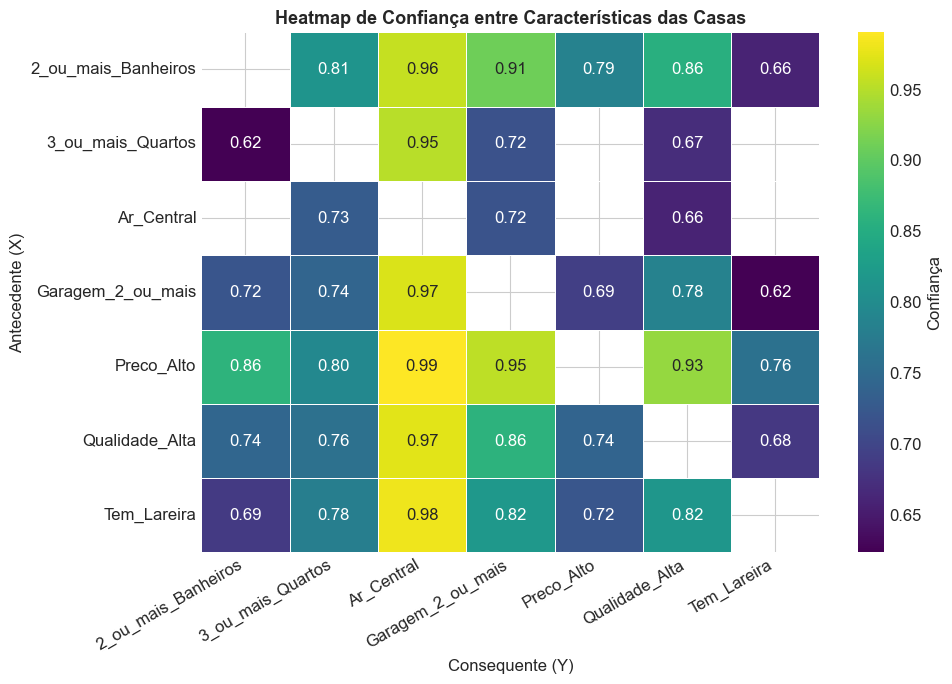

In [402]:
regras_simples = regras[
    (regras['antecedents'].apply(len) == 1) &
    (regras['consequents'].apply(len) == 1)
].copy()

regras_simples['A'] = regras_simples['antecedents'].apply(lambda x: list(x)[0])
regras_simples['C'] = regras_simples['consequents'].apply(lambda x: list(x)[0])

pivot = regras_simples.pivot_table(index='A', columns='C', values='confidence', aggfunc='mean')

if not pivot.empty:
    plt.figure(figsize=(10, 7))
    sns.heatmap(
        pivot,
        annot=True,
        fmt='.2f',
        cmap='viridis',
        linewidths=0.5,
        cbar_kws={'label': 'Confiança'}
    )
    plt.title('Heatmap de Confiança entre Características das Casas', fontsize=13, fontweight='bold')
    plt.xlabel('Consequente (Y)')
    plt.ylabel('Antecedente (X)')
    plt.xticks(rotation=30, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

### Interpretação da Análise de Associação
Padrões encontrados no dataset:

- Casas com qualidade alta + garagem para 2+ carros estão fortemente associadas a preço alto
- Casas com ar central + 2+ banheiros costumam também ter qualidade alta
- Preço alto está associado à combinação de múltiplas comodidades, não apenas uma variável isolada

O Apriori permite descobrir esses padrões de forma objetiva, sem precisar definir hipóteses previamente. Isso é útil para identificar quais combinações de características agregam mais valor a um imóvel.

### 4.2.3 Detecção de Outliers — Local Outlier Factor (LOF)

In [403]:
features_lof = ['GrLivArea', 'SalePrice', 'OverallQual', 'GarageArea',
                'TotalBsmtSF', 'YearBuilt', 'LotArea']

df_lof = df_original[features_lof].copy()

for col in df_lof.columns:
    df_lof[col] = df_lof[col].fillna(df_lof[col].median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_lof)

print(f'Shape dos dados para LOF: {X_scaled.shape}')
print('Dados normalizados com StandardScaler')

Shape dos dados para LOF: (1460, 7)
Dados normalizados com StandardScaler


In [404]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
y_pred = lof.fit_predict(X_scaled)

df_lof['LOF_Score'] = np.abs(lof.negative_outlier_factor_)
df_lof['Outlier']   = y_pred == -1

n_outliers = df_lof['Outlier'].sum()
pct = n_outliers / len(df_lof) * 100

print(f'Outliers detectados: {n_outliers} casas ({pct:.1f}% do dataset)')
print(f'Casas normais:       {len(df_lof) - n_outliers}')

Outliers detectados: 73 casas (5.0% do dataset)
Casas normais:       1387


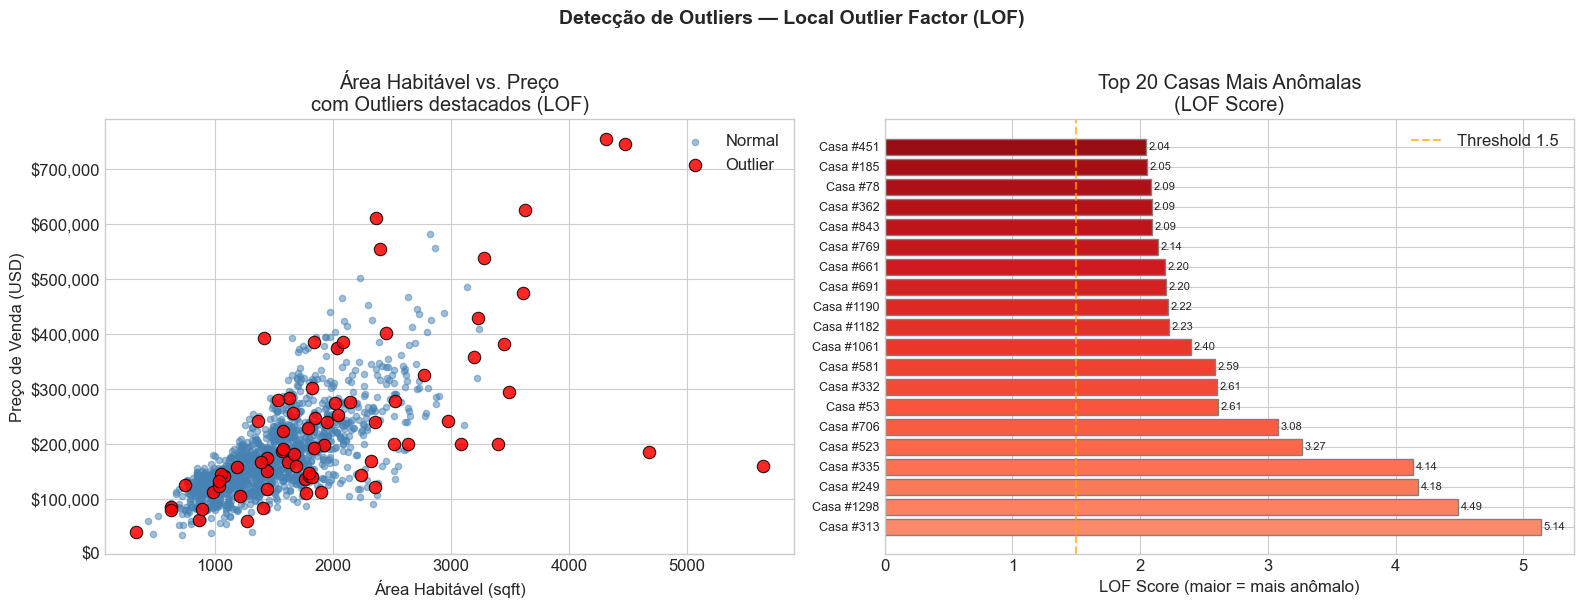

In [405]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Área Habitável x Preço com outliers destacados
axes[0].scatter(
    df_lof.loc[~df_lof['Outlier'], 'GrLivArea'],
    df_lof.loc[~df_lof['Outlier'], 'SalePrice'],
    c='steelblue', s=20, alpha=0.5, label='Normal'
)
axes[0].scatter(
    df_lof.loc[df_lof['Outlier'], 'GrLivArea'],
    df_lof.loc[df_lof['Outlier'], 'SalePrice'],
    c='red', s=80, alpha=0.85, label='Outlier', edgecolors='black', linewidths=0.8
)
axes[0].set_xlabel('Área Habitável (sqft)')
axes[0].set_ylabel('Preço de Venda (USD)')
axes[0].set_title('Área Habitável vs. Preço\ncom Outliers destacados (LOF)')
axes[0].legend()
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Gráfico 2: Top 20 outliers por LOF Score
top_outliers = df_lof[df_lof['Outlier']].nlargest(20, 'LOF_Score').reset_index()
cores_bar = plt.cm.Reds(np.linspace(0.4, 0.9, len(top_outliers)))
bars2 = axes[1].barh(
    range(len(top_outliers)),
    top_outliers['LOF_Score'],
    color=cores_bar, edgecolor='gray'
)
axes[1].set_yticks(range(len(top_outliers)))
axes[1].set_yticklabels([f'Casa #{idx}' for idx in top_outliers['index']], fontsize=9)
axes[1].set_xlabel('LOF Score (maior = mais anômalo)')
axes[1].set_title('Top 20 Casas Mais Anômalas\n(LOF Score)')
axes[1].axvline(x=1.5, color='orange', linestyle='--', alpha=0.7, label='Threshold 1.5')
axes[1].legend()

for bar, val in zip(bars2, top_outliers['LOF_Score']):
    axes[1].text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=8)

plt.suptitle('Detecção de Outliers — Local Outlier Factor (LOF)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [406]:
# Detalhes das 10 casas mais anômalas
print('Detalhes das 10 casas mais anômalas:')
print('-' * 70)
top10 = df_lof[df_lof['Outlier']].nlargest(10, 'LOF_Score')[
    ['GrLivArea', 'SalePrice', 'OverallQual', 'GarageArea', 'YearBuilt', 'LOF_Score']
]
top10.style.format({
    'SalePrice':  '${:,.0f}',
    'GrLivArea':  '{:,.0f} sqft',
    'GarageArea': '{:,.0f} sqft',
    'LOF_Score':  '{:.3f}'
})

Detalhes das 10 casas mais anômalas:
----------------------------------------------------------------------


,GrLivArea,SalePrice,OverallQual,GarageArea,YearBuilt,LOF_Score
313,"2,036 sqft","$375,000",7,513 sqft,1965,5.140
1298,"5,642 sqft","$160,000",10,"1,418 sqft",2008,4.492
249,"2,144 sqft","$277,000",6,389 sqft,1958,4.176
335,"1,786 sqft","$228,950",5,529 sqft,1965,4.140
523,"4,676 sqft","$184,750",10,884 sqft,2007,3.267
706,"1,824 sqft","$302,000",7,739 sqft,1971,3.080
53,"1,842 sqft","$385,000",9,894 sqft,1981,2.608
332,"1,629 sqft","$284,000",8,880 sqft,2003,2.605
581,"2,042 sqft","$253,293",8,"1,390 sqft",2008,2.586
1061,894 sqft,"$81,000",3,"1,248 sqft",1935,2.396


### Interpretação da Detecção de Outliers (LOF)
O LOF identificou casas com comportamento estatisticamente anômalo em relação ao restante do dataset:

- Casas com área muito grande mas preço baixo — podem indicar erro de dados ou localização desfavorável
- Casas com preço muito alto para o tamanho — imóveis premium ou com localização privilegiada
- Terrenos com LotArea extremo — muito fora da faixa típica do conjunto
  
Esses outliers são consistentes com o que o modelo de regressão linear da seção 3 já sinalizava: a diferença entre RMSE (≈ 38k) e MAE (≈ 20k) é grande, indicando a presença de erros muito altos em casos específicos — exatamente os outliers que o LOF encontrou.

---
### 5. Métricas de avaliação e comparação

### 5.1 Glossário das métricas usadas

**Regressão** — prever um valor contínuo (o preço em US$):

| Métrica | O que mede | Melhor quando |
|---------|-----------|---------------|
| **RMSE** | Raiz do erro quadrático médio; pune muito os erros grandes | menor |
| **MAE** | Erro absoluto médio — o erro "típico" em dólares | menor |
| **R²** | Fração da variação do preço explicada pelo modelo (0 a 1) | maior (→1) |

**Classificação** — prever uma categoria (casa cara ou barata):

| Métrica | O que mede | Quando importa |
|---------|-----------|----------------|
| **Acurácia** | % de acertos no total | classes equilibradas |
| **Precisão** | dos que previu "cara", quantos eram de fato | evitar falso alarme |
| **Recall** | das casas caras reais, quantas o modelo achou | não deixar passar nenhuma |
| **F1** | média harmônica entre precisão e recall | métrica-resumo |
| **ROC-AUC** | capacidade de separar as classes (0.5 = acaso, 1 = perfeito) | comparar modelos |

In [407]:
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (12, 6)

# Carrega o dataset já processado pela equipe (mesma base de todos os modelos)
dados = pd.read_csv('dataset_processado.csv')
print(f"Base de avaliação: {dados.shape[0]} casas x {dados.shape[1]} colunas")

Base de avaliação: 1460 casas x 88 colunas


### 5.2 Comparação dos modelos de Regressão

Avaliamos **seis** modelos para prever o preço — do mais simples (Regressão Linear, exigido no desafio) aos baseados em árvores. Todos usam exatamente o mesmo treino e teste.

In [408]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor


X_reg = dados.drop(columns=['Id', 'SalePrice'])
y_reg = dados['SalePrice']
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

reg_models = {
    'Regressão Linear':  LinearRegression(),
    'Ridge':             Ridge(alpha=10.0),
    'Lasso':             Lasso(alpha=100.0),
    'Árvore de Decisão': DecisionTreeRegressor(max_depth=8, random_state=42),
    'Random Forest':     RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                                   max_depth=3, random_state=42),
}

reg_rows, reg_pred = [], {}
for nome, modelo in reg_models.items():
    modelo.fit(Xr_tr, yr_tr)
    p = modelo.predict(Xr_te)
    reg_pred[nome] = p
    reg_rows.append({
        'Modelo': nome,
        'RMSE (US$)': np.sqrt(mean_squared_error(yr_te, p)),
        'MAE (US$)':  mean_absolute_error(yr_te, p),
        'R²':         r2_score(yr_te, p),
    })

reg_resultados = pd.DataFrame(reg_rows).sort_values('R²', ascending=False).reset_index(drop=True)
reg_resultados.round(4)

,Modelo,RMSE (US$),MAE (US$),R²
0,Gradient Boosting,26780.8333,15842.7321,0.9065
1,Random Forest,29220.0420,17687.4973,0.8887
2,Ridge,35467.0805,20870.5050,0.8360
3,Lasso,37291.0701,20629.0466,0.8187
4,Regressão Linear,38199.9370,20732.6470,0.8098
5,Árvore de Decisão,40783.2084,24826.5003,0.7832


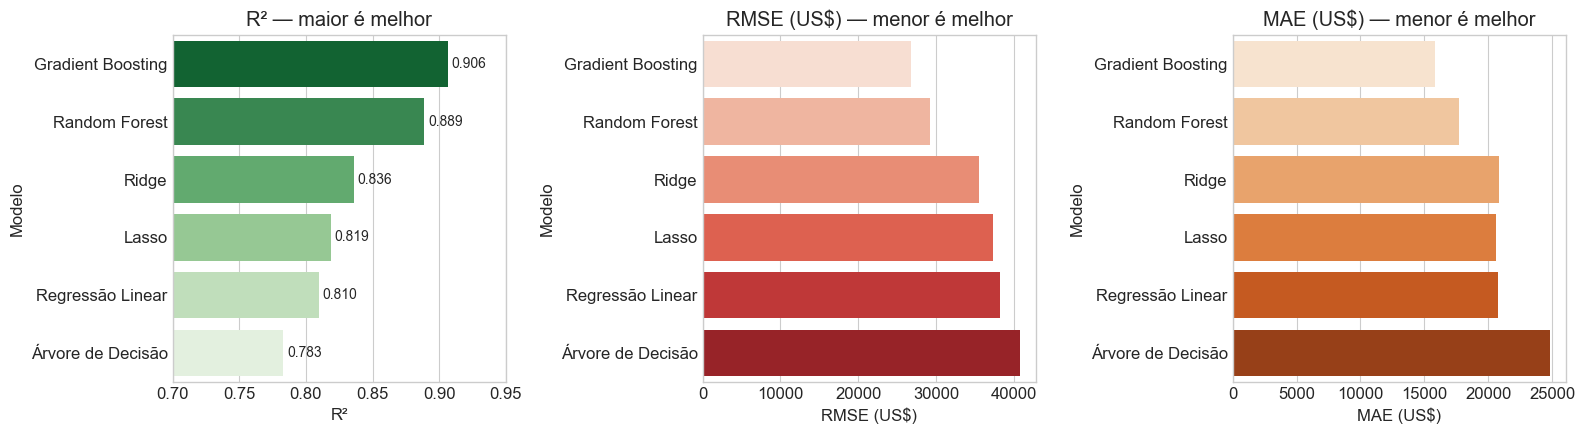

In [409]:
ordem = reg_resultados['Modelo']
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.barplot(data=reg_resultados, x='R²', y='Modelo', order=ordem, ax=axes[0], palette='Greens_r')
axes[0].set_title('R² — maior é melhor'); axes[0].set_xlim(0.7, 0.95)
for i, v in enumerate(reg_resultados.set_index('Modelo').loc[ordem, 'R²']):
    axes[0].text(v + 0.003, i, f'{v:.3f}', va='center', fontsize=10)

sns.barplot(data=reg_resultados, x='RMSE (US$)', y='Modelo', order=ordem, ax=axes[1], palette='Reds')
axes[1].set_title('RMSE (US$) — menor é melhor')

sns.barplot(data=reg_resultados, x='MAE (US$)', y='Modelo', order=ordem, ax=axes[2], palette='Oranges')
axes[2].set_title('MAE (US$) — menor é melhor')
plt.tight_layout(); plt.show()

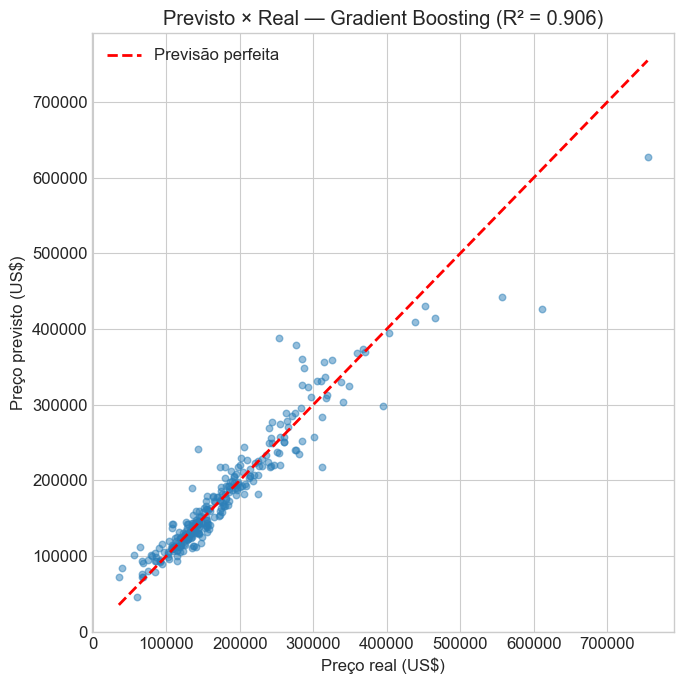

In [410]:
# Previsto vs Real para o melhor regressor
melhor_reg = reg_resultados.iloc[0]['Modelo']
p_best = reg_pred[melhor_reg]

plt.figure(figsize=(7, 7))
plt.scatter(yr_te, p_best, alpha=0.5, color='#2c7fb8', s=22)
lims = [yr_te.min(), yr_te.max()]
plt.plot(lims, lims, 'r--', lw=2, label='Previsão perfeita')
plt.xlabel('Preço real (US$)'); plt.ylabel('Preço previsto (US$)')
plt.title(f'Previsto × Real — {melhor_reg} (R² = {reg_resultados.iloc[0]["R²"]:.3f})')
plt.legend(); plt.tight_layout(); plt.show()

*Conclusão da regressão:**
- A **Regressão Linear** (modelo exigido) explica cerca de **81%** da variação do preço — um resultado sólido e altamente interpretável para um modelo simples.
- O **Gradient Boosting** lidera com **R² ≈ 0.91** e erro médio (MAE) em torno de **US$ 16 mil**, porque captura relações **não lineares** entre as características e o preço.
- **Trade-off prático:** se a imobiliária precisa *explicar* o preço ao cliente, a Regressão Linear é preferível; se quer *máxima precisão*, os modelos de árvore (Gradient Boosting / Random Forest) ganham.

### 5.3 Comparação dos modelos de Classificação

O alvo binário (`PrecoAlto`) marca casas **acima da mediana** como "caras" (1) e abaixo como "baratas" (0) — o mesmo critério usado na seção de Regressão Logística. Comparamos **cinco** classificadores.

In [411]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier


y_clf = (dados['SalePrice'] > dados['SalePrice'].median()).astype(int)
X_clf = dados.drop(columns=['Id', 'SalePrice'])
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(X_clf, y_clf, test_size=0.2,
                                              random_state=42, stratify=y_clf)

clf_models = {
    'Regressão Logística': LogisticRegression(max_iter=1000),
    'KNN':                 KNeighborsClassifier(n_neighbors=7),
    'Árvore de Decisão':   DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                                      max_depth=3, random_state=42),
}

clf_rows, clf_proba, clf_pred = [], {}, {}
for nome, modelo in clf_models.items():
    modelo.fit(Xc_tr, yc_tr)
    p  = modelo.predict(Xc_te)
    pr = modelo.predict_proba(Xc_te)[:, 1]
    clf_pred[nome], clf_proba[nome] = p, pr
    clf_rows.append({
        'Modelo':   nome,
        'Acurácia': accuracy_score(yc_te, p),
        'Precisão': precision_score(yc_te, p),
        'Recall':   recall_score(yc_te, p),
        'F1':       f1_score(yc_te, p),
        'ROC-AUC':  roc_auc_score(yc_te, pr),
    })

clf_resultados = pd.DataFrame(clf_rows).sort_values('F1', ascending=False).reset_index(drop=True)
clf_resultados.round(4)

,Modelo,Acurácia,Precisão,Recall,F1,ROC-AUC
0,Random Forest,0.9247,0.9429,0.9041,0.9231,0.9799
1,Regressão Logística,0.9212,0.9184,0.9247,0.9215,0.9628
2,Gradient Boosting,0.9212,0.9362,0.9041,0.9199,0.9840
3,KNN,0.9075,0.9161,0.8973,0.9066,0.9546
4,Árvore de Decisão,0.8938,0.8859,0.9041,0.8949,0.9160


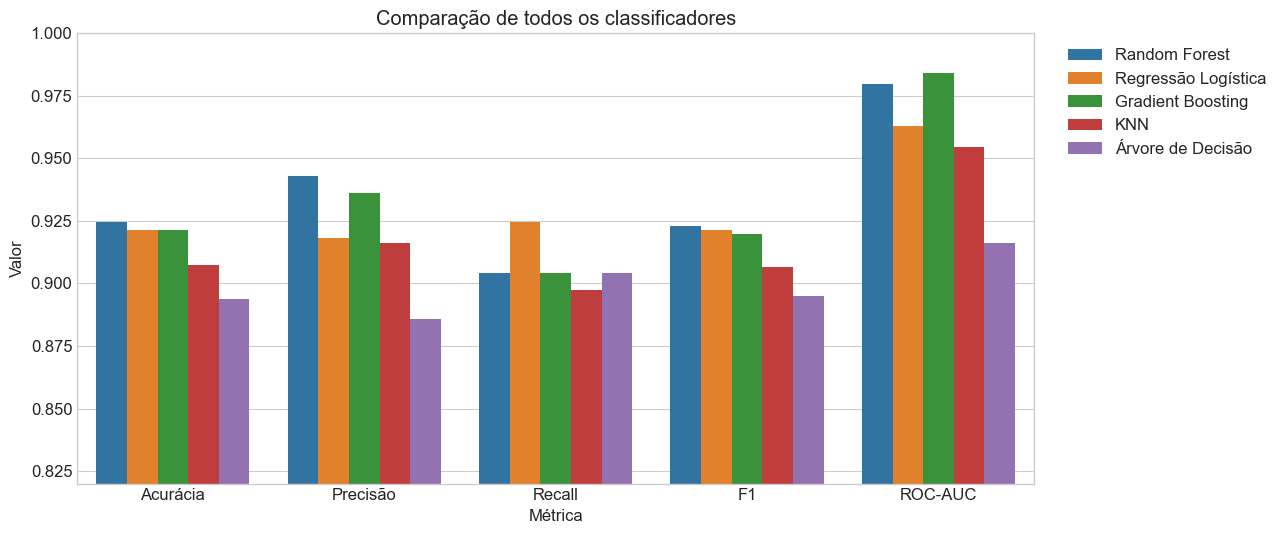

In [412]:
metricas = ['Acurácia', 'Precisão', 'Recall', 'F1', 'ROC-AUC']
melt = clf_resultados.melt(id_vars='Modelo', value_vars=metricas,
                           var_name='Métrica', value_name='Valor')

plt.figure(figsize=(13, 5.5))
sns.barplot(data=melt, x='Métrica', y='Valor', hue='Modelo', palette='tab10')
plt.title('Comparação de todos os classificadores'); plt.ylim(0.82, 1.0)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left'); plt.tight_layout(); plt.show()

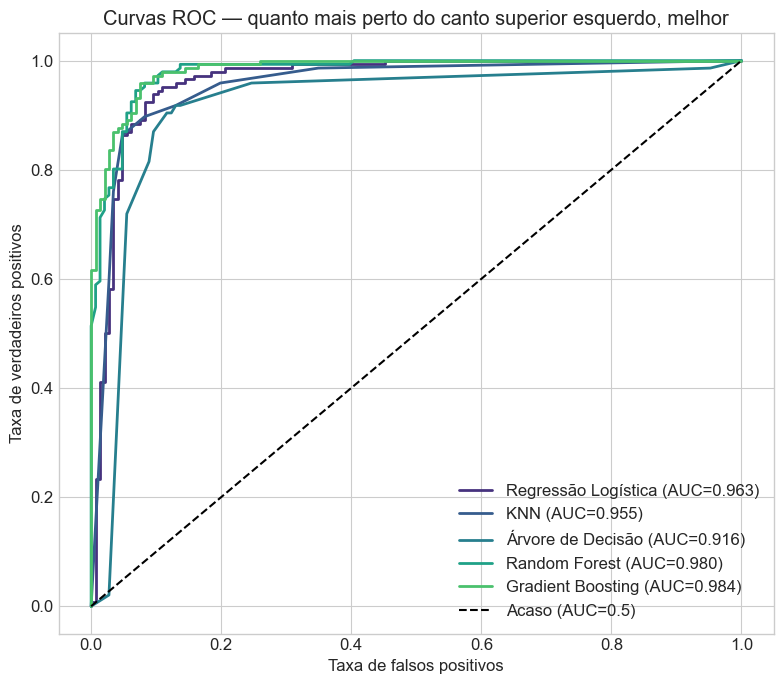

In [413]:
# Curvas ROC de todos os classificadores
from sklearn.metrics import roc_curve


plt.figure(figsize=(8, 7))
for nome in clf_models:
    fpr, tpr, _ = roc_curve(yc_te, clf_proba[nome])
    auc = roc_auc_score(yc_te, clf_proba[nome])
    plt.plot(fpr, tpr, lw=2, label=f'{nome} (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Acaso (AUC=0.5)')
plt.xlabel('Taxa de falsos positivos'); plt.ylabel('Taxa de verdadeiros positivos')
plt.title('Curvas ROC — quanto mais perto do canto superior esquerdo, melhor')
plt.legend(loc='lower right'); plt.tight_layout(); plt.show()

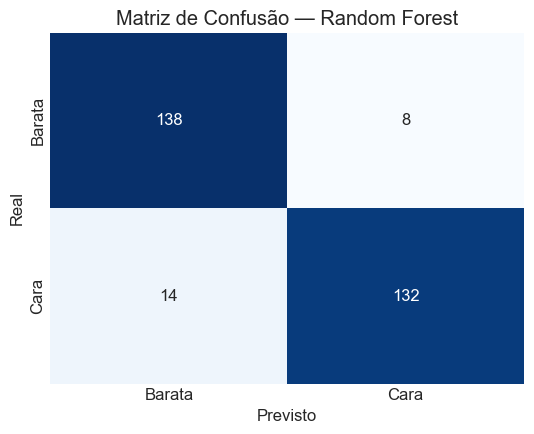

Relatório de classificação — Random Forest:

              precision    recall  f1-score   support

      Barata       0.91      0.95      0.93       146
        Cara       0.94      0.90      0.92       146

    accuracy                           0.92       292
   macro avg       0.93      0.92      0.92       292
weighted avg       0.93      0.92      0.92       292



In [414]:
# Matriz de confusão do melhor classificador
melhor_clf = clf_resultados.iloc[0]['Modelo']
cm = confusion_matrix(yc_te, clf_pred[melhor_clf])

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Barata', 'Cara'], yticklabels=['Barata', 'Cara'])
plt.title(f'Matriz de Confusão — {melhor_clf}')
plt.ylabel('Real'); plt.xlabel('Previsto'); plt.tight_layout(); plt.show()

print(f"Relatório de classificação — {melhor_clf}:\n")
print(classification_report(yc_te, clf_pred[melhor_clf], target_names=['Barata', 'Cara']))

** Conclusão da classificação:**
- Todos os modelos passam de **89% de acurácia** — o problema "cara vs barata" é bem separável.
- A **Regressão Logística** (modelo exigido) já entrega F1 ≈ 0.92, praticamente empatada com os modelos de árvore, com a vantagem de ser interpretável.
- O **Gradient Boosting** tem o melhor ROC-AUC (≈ 0.98), ou seja, a melhor capacidade de ordenar casas por probabilidade de serem caras.
- A matriz de confusão mostra **poucos erros**, distribuídos de forma equilibrada entre as duas classes.

### 5.4 Comparação geral: supervisionado × não supervisionado

A comparação mais importante não é só "qual modelo ganha", mas **o que cada abordagem entrega** ao projeto:

| Aspecto | Supervisionado (Regressão / Classificação) | Não Supervisionado (Cluster / PCA / Apriori / LOF) |
|---------|---------------------------------------------|-----------------------------------------------------|
| **Precisa de rótulo?** | Sim — sabemos o preço real | Não |
| **Responde** | *"Quanto vale? É cara?"* | *"Que padrões existem nos dados?"* |
| **Como se avalia** | RMSE, MAE, R², F1, ROC-AUC | Silhouette, variância explicada (PCA), lift (Apriori) |
| **Melhor resultado** | Gradient Boosting (R² ≈ 0.91 / F1 ≈ 0.92) | 4 clusters; PCA retém ~70%; regras com lift > 1 |
| **Validável contra a "verdade"?** | Sim (temos o gabarito) | Não diretamente — exige interpretação |

**Síntese:** as duas abordagens **se complementam**. O não supervisionado *descobriu* a estrutura do mercado (grupos de imóveis no K-Means, o eixo de valor no PCA, combinações frequentes no Apriori). O supervisionado *confirmou e quantificou* essa estrutura, prevendo o preço com erro médio de ~US$ 16 mil. O fato de a clusterização reproduzir a faixa de preços **sem nunca tê-la visto** funciona como uma validação qualitativa do que os modelos supervisionados aprenderam.

In [415]:
# Placar final consolidado do projeto
print("="*62)
print("PLACAR FINAL DO PROJETO".center(62))
print("="*62)
print("\n▶ REGRESSÃO (prever o preço em US$):")
print(reg_resultados[['Modelo','R²','RMSE (US$)','MAE (US$)']].round(3).to_string(index=False))
print(f"\n  🏆 Melhor: {reg_resultados.iloc[0]['Modelo']} "
      f"(R² = {reg_resultados.iloc[0]['R²']:.3f})")
print("\n▶ CLASSIFICAÇÃO (casa cara vs barata):")
print(clf_resultados[['Modelo','Acurácia','F1','ROC-AUC']].round(3).to_string(index=False))
print(f"\n  🏆 Melhor: {clf_resultados.iloc[0]['Modelo']} "
      f"(F1 = {clf_resultados.iloc[0]['F1']:.3f})")
print("="*62)

                   PLACAR FINAL DO PROJETO                    

▶ REGRESSÃO (prever o preço em US$):
           Modelo    R²  RMSE (US$)  MAE (US$)
Gradient Boosting 0.906   26780.833  15842.732
    Random Forest 0.889   29220.042  17687.497
            Ridge 0.836   35467.080  20870.505
            Lasso 0.819   37291.070  20629.047
 Regressão Linear 0.810   38199.937  20732.647
Árvore de Decisão 0.783   40783.208  24826.500

  🏆 Melhor: Gradient Boosting (R² = 0.906)

▶ CLASSIFICAÇÃO (casa cara vs barata):
             Modelo  Acurácia    F1  ROC-AUC
      Random Forest     0.925 0.923    0.980
Regressão Logística     0.921 0.922    0.963
  Gradient Boosting     0.921 0.920    0.984
                KNN     0.908 0.907    0.955
  Árvore de Decisão     0.894 0.895    0.916

  🏆 Melhor: Random Forest (F1 = 0.923)


---
# 6. Conclusão —

> Pergunta inicial: *É possível prever o preço de uma casa a partir das suas características, e descobrir padrões escondidos no mercado?* **A resposta é sim.**


1. **Conhecemos o terreno (EDA):** O preço é fortemente assimétrico e movido, acima de tudo, por **qualidade geral e tamanho** (`OverallQual`, `GrLivArea`, área total).
2. **Preparamos os dados (Feature Engineering):** Tratamos ausências com significado de negócio, criamos features que resumem o imóvel (área total, idade, banheiros) e deixamos a base 100% numérica.
3. **Regressão** Do modelo linear: (R² ≈ 0.81) ao Gradient Boosting (R² ≈ 0.91, erro de ~US$ 16 mil) num mercado de US$ 35 mil a US$ 755 mil.
4. **Classificação:** Acerto de ~92% de F1 — útil para filtros rápidos e segmentação.
5. **Não supervisionado:** ~4 perfis naturais de imóveis (econômico → premium), um mapa 2D do mercado via PCA, regras de associação (qualidade + tamanho ⇒ caro) e ~5% de imóveis atípicos sinalizados pelo LOF.
6. **Métricas:** Gradient Boosting vence em precisão; os modelos lineares vencem em interpretabilidade.

**Recomendação prática para a imobiliária:** usar a **Regressão Linear/Logística** quando for preciso *explicar* o preço ao cliente, e o **Gradient Boosting** como motor de *precisão* nos bastidores; alimentar o time comercial com os **grupos do K-Means** e as **regras do Apriori**; e enviar os **outliers do LOF** para avaliação humana antes de confiar no modelo.

**Limitações e próximos passos:** os dados vêm de uma única cidade (Ames, Iowa) e período específico. Um sistema real exigiria mais bairros, validação temporal e reavaliação periódica do modelo.